In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../fraudTest.csv')

In [3]:
# displays all columns 
pd.set_option('display.max_columns', None)

In [4]:
df.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,Columbia,SC,29209,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,Altonah,UT,84002,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,Bellmore,NY,11710,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,Titusville,FL,32780,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,Falmouth,MI,49632,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0


In [5]:
df.drop(df.columns[0], axis=1, inplace=True)

In [6]:
df.sample()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
359568,2020-11-08 01:51:00,4410582919485061752,fraud_Balistreri-Nader,misc_pos,4.56,David,Cole,M,7955 Allen Orchard Apt. 336,Springfield,GA,31329,32.3697,-81.3618,9034,"Therapist, occupational",1969-03-02,c824bad1b9724a6f7b566a01875fc404,1383875460,31.477914,-81.058081,0


In [7]:
df.describe()

,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud
count,5.557190e+05,555719.000000,555719.000000,555719.000000,555719.000000,5.557190e+05,5.557190e+05,555719.000000,555719.000000,555719.000000
mean,4.178387e+17,69.392810,48842.628015,38.543253,-90.231325,8.822189e+04,1.380679e+09,38.542798,-90.231380,0.003860
std,1.309837e+18,156.745941,26855.283328,5.061336,13.721780,3.003909e+05,5.201104e+06,5.095829,13.733071,0.062008
min,6.041621e+10,1.000000,1257.000000,20.027100,-165.672300,2.300000e+01,1.371817e+09,19.027422,-166.671575,0.000000
25%,1.800429e+14,9.630000,26292.000000,34.668900,-96.798000,7.410000e+02,1.376029e+09,34.755302,-96.905129,0.000000
50%,3.521417e+15,47.290000,48174.000000,39.371600,-87.476900,2.408000e+03,1.380762e+09,39.376593,-87.445204,0.000000
75%,4.635331e+15,83.010000,72011.000000,41.894800,-80.175200,1.968500e+04,1.385867e+09,41.954163,-80.264637,0.000000
max,4.992346e+18,22768.110000,99921.000000,65.689900,-67.950300,2.906700e+06,1.388534e+09,66.679297,-66.952026,1.000000


### Category Column

In [8]:
import pandas as pd

total_counts_by_category = df['category'].value_counts()

fraud_counts_by_category = df.groupby('category')['is_fraud'].sum()

# Step 3: Calculate non-fraudulent transactions
non_fraud_counts_by_category = total_counts_by_category - fraud_counts_by_category

fraud_ratio_by_category = fraud_counts_by_category / total_counts_by_category

# Step 5: Combine the results into a single DataFrame
combined_counts = pd.DataFrame({
    'total_tran': total_counts_by_category,
    'total_frauds': fraud_counts_by_category,
    'fraud_ratio': fraud_ratio_by_category,
    'total_non_frauds': non_fraud_counts_by_category,

}).fillna(0)  # Fill NaN with 0 for categories with no frauds

combined_counts_category_sorted = combined_counts.sort_values(by='total_frauds', ascending=False)

print(combined_counts_category_sorted)


                total_tran  total_frauds  fraud_ratio  total_non_frauds
category                                                               
shopping_net         41779           506     0.012111             41273
grocery_pos          52553           485     0.009229             52068
misc_net             27367           267     0.009756             27100
shopping_pos         49791           213     0.004278             49578
gas_transport        56370           154     0.002732             56216
misc_pos             34574            72     0.002082             34502
personal_care        39327            70     0.001780             39257
home                 52345            67     0.001280             52278
kids_pets            48692            65     0.001335             48627
entertainment        40104            59     0.001471             40045
food_dining          39268            54     0.001375             39214
health_fitness       36674            52     0.001418           

/var/folders/tt/ndzk13v944z9y5c79vdqq_mr0000gp/T/ipykernel_19816/3902720609.py:8: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax1.set_xticklabels(combined_counts_category_sorted.index, rotation=90)


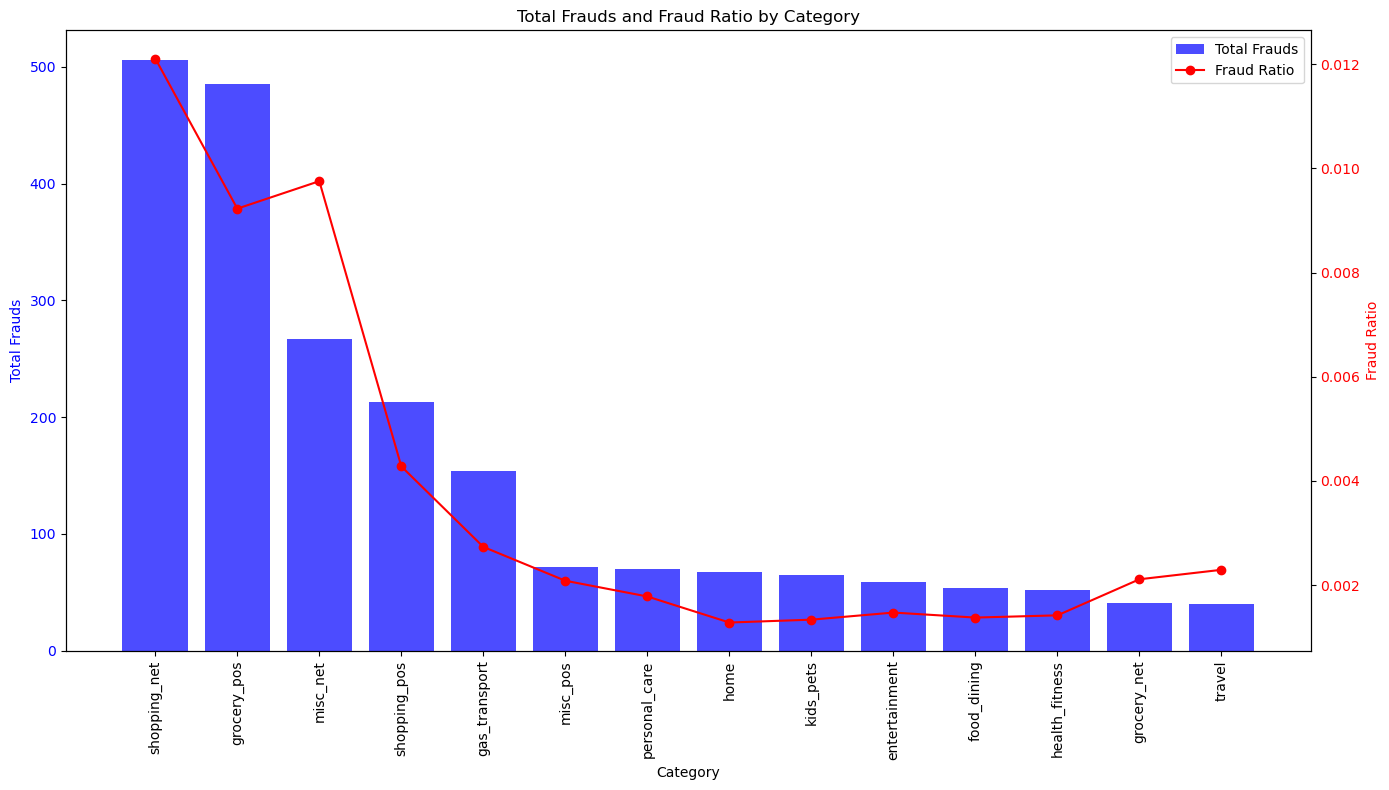

In [9]:
# Plotting the bar graph
fig, ax1 = plt.subplots(figsize=(14, 8))

ax1.bar(combined_counts_category_sorted.index, combined_counts_category_sorted['total_frauds'], color='b', alpha=0.7, label='Total Frauds')
ax1.set_xlabel('Category')
ax1.set_ylabel('Total Frauds', color='b')
ax1.tick_params(axis='y', labelcolor='b')
ax1.set_xticklabels(combined_counts_category_sorted.index, rotation=90)

# Create a secondary y-axis for the fraud ratio
ax2 = ax1.twinx()
ax2.plot(combined_counts_category_sorted.index, combined_counts_category_sorted['fraud_ratio'], color='r', marker='o', label='Fraud Ratio')
ax2.set_ylabel('Fraud Ratio', color='r')
ax2.tick_params(axis='y', labelcolor='r')

# Title and legend
plt.title('Total Frauds and Fraud Ratio by Category')
fig.tight_layout()
fig.legend(loc='upper right', bbox_to_anchor=(1,1), bbox_transform=ax1.transAxes)

# Show the plot
plt.show()

### Gender

In [10]:
df['gender'].value_counts()

gender
F    304886
M    250833
Name: count, dtype: int64

In [11]:
# Count occurrences of each credit card number
cc_num_counts = df['cc_num'].value_counts()

### credit card that were envolved in fraud (more than 1000 data in dataset)

In [12]:
# Filter credit card numbers with counts greater than or equal to 1000
cc_num_counts_filtered_morethan_1000 = cc_num_counts[cc_num_counts >= 1000]

# Filter the original DataFrame to include only the filtered credit card numbers
filtered_df_morethan_1000 = df[df['cc_num'].isin(cc_num_counts_filtered_morethan_1000.index)]

# Group by 'cc_num' and count 'is_fraud' occurrences
fraud_counts_morethan_1000 = filtered_df_morethan_1000.groupby('cc_num')['is_fraud'].sum()

# Filter fraud counts to display only where fraud count is at least 1
fraud_counts_filtered_morethan_1000 = fraud_counts_morethan_1000[fraud_counts_morethan_1000 >= 1]

# Calculate the total sum of fraudulent transactions
total_fraud_sum_morethan_1000 = fraud_counts_filtered_morethan_1000.sum()

# Print the results
# print("Credit card numbers with at least 1 fraudulent transaction:")
# print(fraud_counts_filtered_morethan_1000)

print("\nTotal sum of fraudulent transactions:")
print(total_fraud_sum_morethan_1000)



Total sum of fraudulent transactions:
312


### credit card that were envolved in fraud (less than 1000 data in dataset)

In [13]:
# Filter credit card numbers with counts greater than or equal to 1000
cc_num_counts_filtered_lessthan_1000 = cc_num_counts[cc_num_counts < 1000]

# Filter the original DataFrame to include only the filtered credit card numbers
filtered_df_lessthan_1000 = df[df['cc_num'].isin(cc_num_counts_filtered_lessthan_1000.index)]

# Group by 'cc_num' and count 'is_fraud' occurrences
fraud_counts_lessthan_1000 = filtered_df_lessthan_1000.groupby('cc_num')['is_fraud'].sum()

# Filter fraud counts to display only where fraud count is at least 1
fraud_counts_filtered_lessthan_1000= fraud_counts_lessthan_1000[fraud_counts_lessthan_1000 >= 1]

# Calculate the total sum of fraudulent transactions
total_fraud_sum_lessthan_1000 = fraud_counts_filtered_lessthan_1000.sum()

# Print the results
# print("Credit card numbers with at least 1 fraudulent transaction:")
# print(fraud_counts_filtered_lessthan_1000)

print("\nTotal sum of fraudulent transactions:")
print(total_fraud_sum_lessthan_1000)


Total sum of fraudulent transactions:
1833


In [14]:
df[['is_fraud']].value_counts()

is_fraud
0           553574
1             2145
Name: count, dtype: int64

In [15]:
df.isna().sum()

trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

In [16]:
duplicates = df[df.duplicated()]
duplicates

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud


In [17]:
df.dtypes

trans_date_trans_time     object
cc_num                     int64
merchant                  object
category                  object
amt                      float64
first                     object
last                      object
gender                    object
street                    object
city                      object
state                     object
zip                        int64
lat                      float64
long                     float64
city_pop                   int64
job                       object
dob                       object
trans_num                 object
unix_time                  int64
merch_lat                float64
merch_long               float64
is_fraud                   int64
dtype: object

## Data and Time Series

In [18]:
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])

In [19]:
df['dob'] = pd.to_datetime(df['dob'])

In [20]:
df['dob'].isna().sum()

0

In [21]:
df['year'] = df['trans_date_trans_time'].dt.year
df['month'] = df['trans_date_trans_time'].dt.month
df['day'] = df['trans_date_trans_time'].dt.day
df['time'] = df['trans_date_trans_time'].dt.time

In [22]:
df.sample()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,year,month,day,time
206103,2020-09-01 11:01:45,30376238035123,"fraud_Kerluke, Considine and Macejkovic",misc_net,8.14,Cynthia,Davis,F,7177 Steven Forges,Sixes,OR,97476,42.825,-124.4409,217,Retail merchandiser,1928-10-01,92d1e8c5672f8635f6b838939660c9d5,1378033305,42.040085,-124.460785,0,2020,9,1,11:01:45


In [23]:
df.head()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,year,month,day,time
0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,Columbia,SC,29209,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0,2020,6,21,12:14:25
1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,Altonah,UT,84002,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0,2020,6,21,12:14:33
2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,Bellmore,NY,11710,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0,2020,6,21,12:14:53
3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,Titusville,FL,32780,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0,2020,6,21,12:15:15
4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,Falmouth,MI,49632,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0,2020,6,21,12:15:17


In [24]:
df['month'].value_counts()

month
12    139538
8      88759
7      85848
11     72635
9      69533
10     69348
6      30058
Name: count, dtype: int64

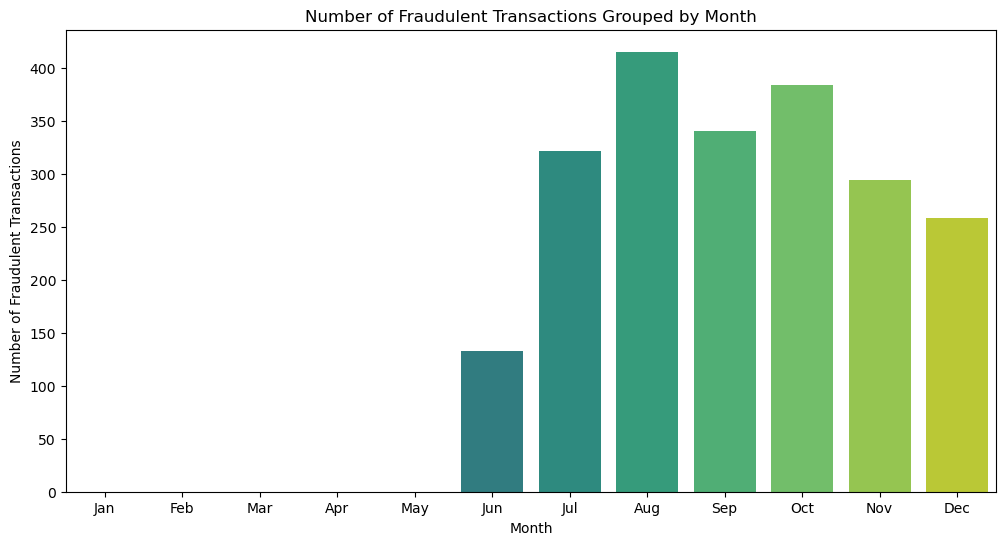

In [25]:
# Filter only fraudulent transactions
fraud_df = df[df['is_fraud'] == 1]

# Group by month and count the transactions
monthly_fraud_transactions = fraud_df.groupby('month').size().reset_index(name='fraud_transaction_count')

# Create a complete set of months (from 1 to 12)
all_months = pd.DataFrame({'month': range(1, 13)})

# Merge with the actual data to fill missing months
monthly_fraud_transactions = all_months.merge(monthly_fraud_transactions, on='month', how='left').fillna(0)

# Map month numbers to month names
month_names = {1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'}
monthly_fraud_transactions['month'] = monthly_fraud_transactions['month'].map(month_names)

# Plotting
plt.figure(figsize=(12, 6))
sns.barplot(data=monthly_fraud_transactions, x='month', y='fraud_transaction_count', palette='viridis')

plt.title('Number of Fraudulent Transactions Grouped by Month')
plt.xlabel('Month')
plt.ylabel('Number of Fraudulent Transactions')
plt.show()

In [26]:
### 

In [27]:
df['time'] = pd.to_datetime(df.time, format='%H:%M:%S')

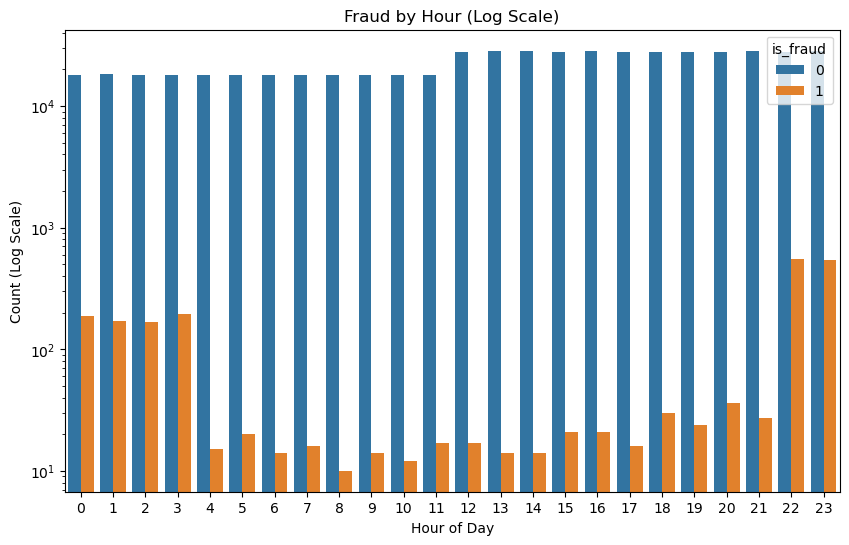

In [28]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(x=df['time'].dt.hour, hue=df['is_fraud'])
ax.set_yscale('log')
plt.title('Fraud by Hour (Log Scale)')
plt.xlabel('Hour of Day')
plt.ylabel('Count (Log Scale)')
plt.show()

In [29]:
# plt.figure(figsize=(10, 6))
# sns.countplot(x=df['time'].dt.minute.dropna(), hue=df['is_fraud'])
# plt.title('Fraud by Minute')
# plt.xlabel('Minute of Hour')
# plt.ylabel('Count')
# plt.show()

In [30]:
# plt.figure(figsize=(10, 6))
# sns.countplot(x=df['time'].dt.second.dropna(), hue=df['is_fraud'])
# plt.title('Fraud by Second')
# plt.xlabel('Second of Minute')
# plt.ylabel('Count')
# plt.show()

In [31]:
df['time'].isna().sum()

0

In [32]:
df.sample()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,year,month,day,time
458917,2020-12-10 14:15:44,4040099974063068803,fraud_Waters-Cruickshank,health_fitness,75.08,Jeffrey,Lewis,M,24255 Bryan Square,Palermo,ND,58769,48.3396,-102.24,229,Administrator,1983-03-20,592f6ee5765cbc414ac0f96c19b5bcc2,1386684944,48.058201,-101.676035,0,2020,12,10,1900-01-01 14:15:44


In [33]:
# plt.figure(figsize=(10, 6))
# sns.countplot(x=df['time'].dt.hour, hue=df['is_fraud'])
# plt.title('Fraud by Hour')
# plt.xlabel('Hour of Day')
# plt.ylabel('Count')
# plt.show()

In [34]:
# plt.figure(figsize=(10, 6))
# sns.countplot(data=df, x='hour', hue='is_fraud')
# plt.title('Fraud by Hour')
# plt.show()

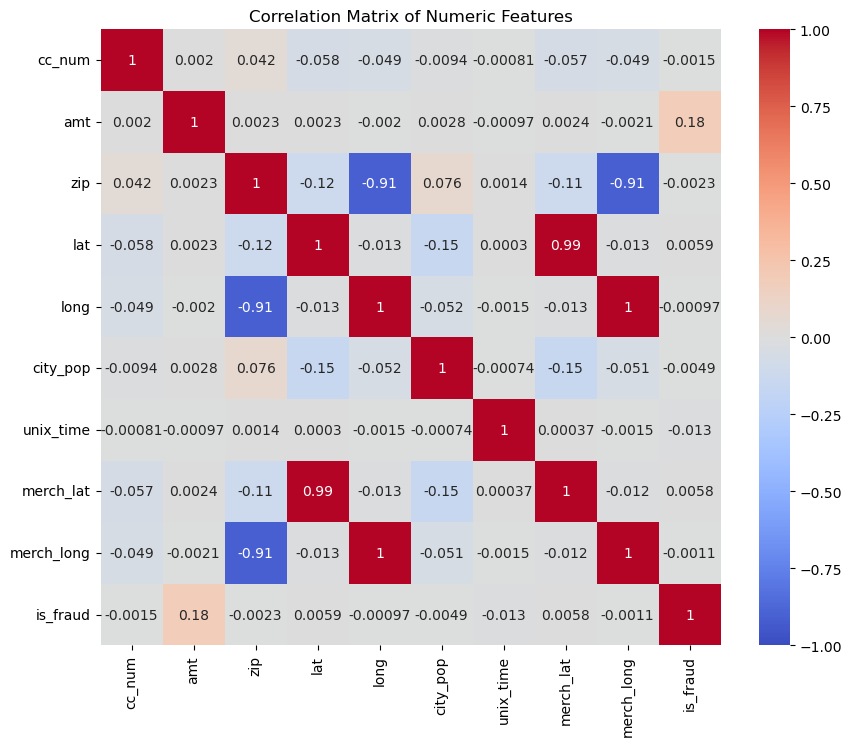

In [35]:
# Select only numeric columns (float and int)
numeric_cols = df.select_dtypes(include=['float64', 'int64'])

# Calculate correlation matrix
correlation_matrix = numeric_cols.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Matrix of Numeric Features')
plt.show()

### Tried to plot the number of fraud using lat and long

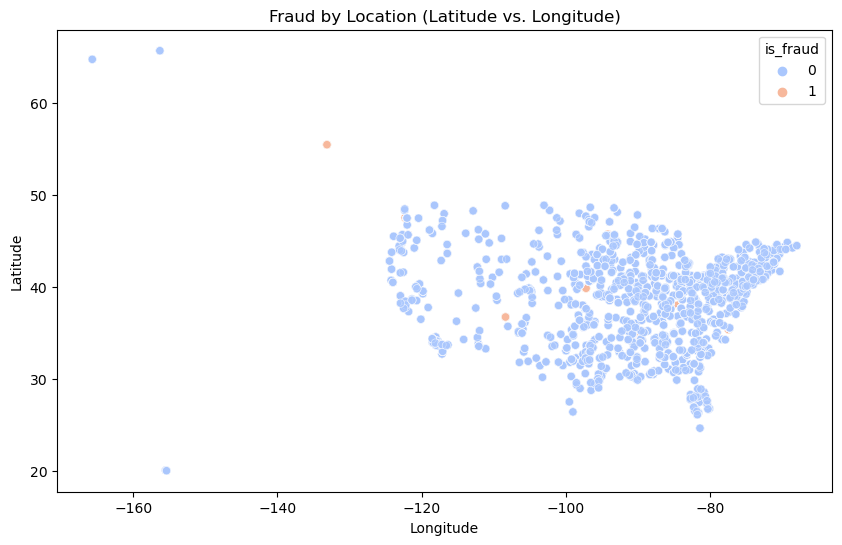

In [36]:
import geopandas as gpd
import contextily as ctx


# Scatter plot of latitude and longitude to visualize fraud occurrences
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='long', y='lat', hue='is_fraud', palette='coolwarm', alpha=0.7)
plt.title('Fraud by Location (Latitude vs. Longitude)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()


### Looking at the City Polulation in relation to Amount and Fraud

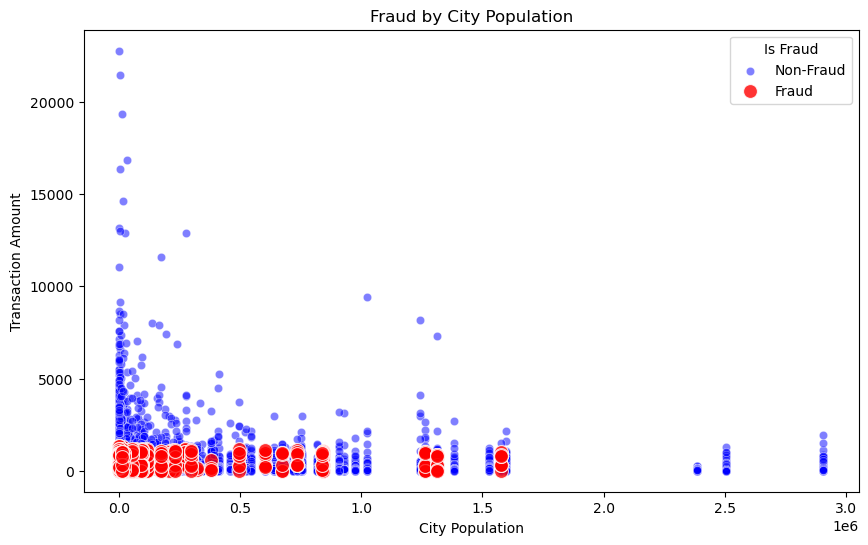

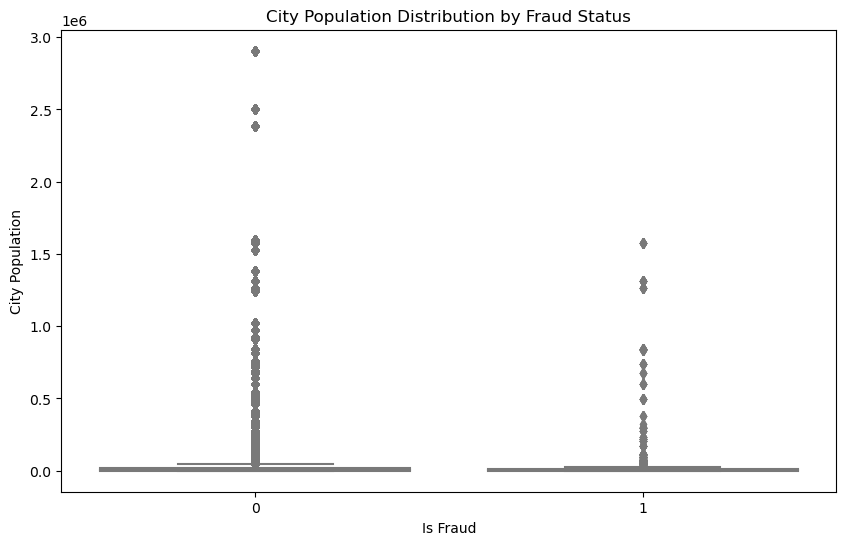

In [37]:
# Separate the data into fraudulent and non-fraudulent transactions
df_fraud = df[df['is_fraud'] == 1]
df_non_fraud = df[df['is_fraud'] == 0]

# Scatter plot of city population to visualize fraud occurrences
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_non_fraud, x='city_pop', y='amt', color='blue', alpha=0.5, label='Non-Fraud')
sns.scatterplot(data=df_fraud, x='city_pop', y='amt', color='red', s=100, alpha=0.8, label='Fraud')
plt.title('Fraud by City Population')
plt.xlabel('City Population')
plt.ylabel('Transaction Amount')
plt.legend(title='Is Fraud', loc='upper right')
plt.show()

# Box plot of city population for fraudulent and non-fraudulent transactions
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='is_fraud', y='city_pop', palette='coolwarm')
plt.title('City Population Distribution by Fraud Status')
plt.xlabel('Is Fraud')
plt.ylabel('City Population')
plt.show()

In [38]:
df.sample()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,year,month,day,time
476168,2020-12-14 12:32:24,3527536963490470,fraud_Heathcote LLC,shopping_net,2.34,Teresa,Stein,F,2838 White Fields Apt. 473,Brunson,SC,29911,32.9413,-81.1807,1725,Social researcher,1974-12-05,ddddbf018d10bd3be3a4a0c9ae9f19e0,1387024344,32.281493,-81.183828,0,2020,12,14,1900-01-01 12:32:24


### Looked into the amount

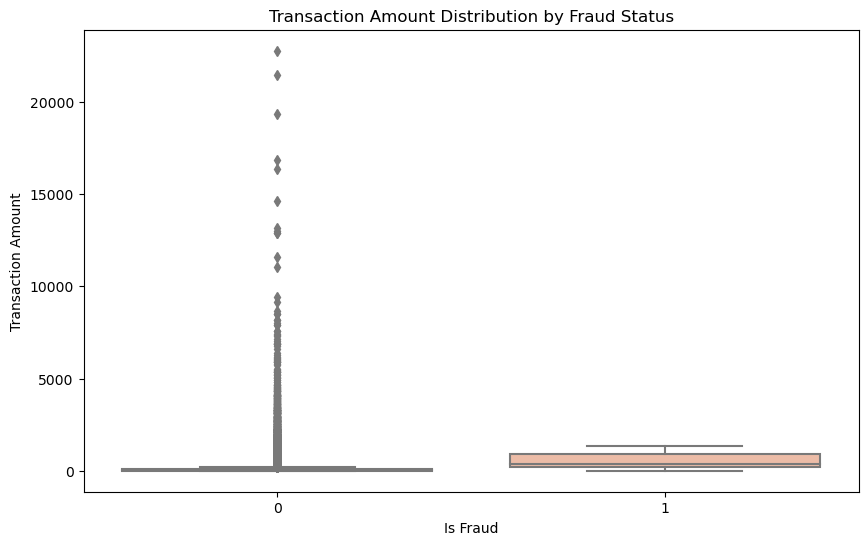

In [39]:
# Box plot of transaction amount
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='is_fraud', y='amt', palette='coolwarm')
plt.title('Transaction Amount Distribution by Fraud Status')
plt.xlabel('Is Fraud')
plt.ylabel('Transaction Amount')
plt.show()



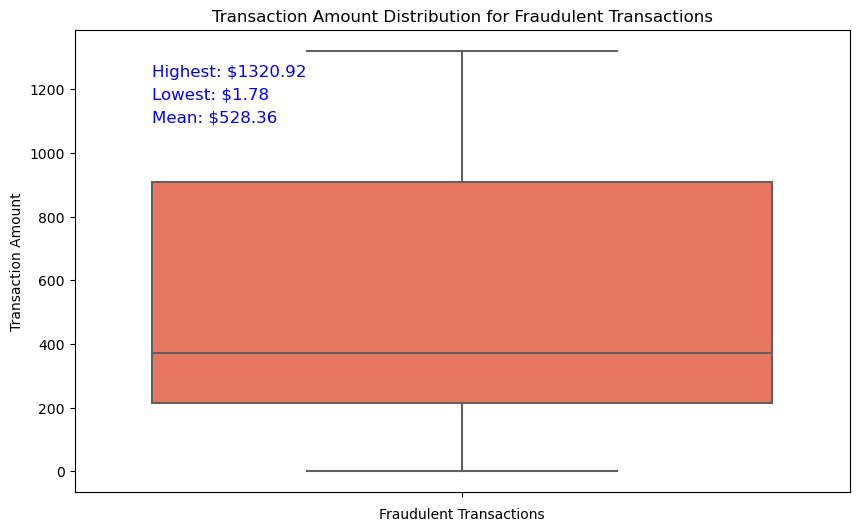

In [40]:

df_fraud = df[df['is_fraud'] == 1]

highest_amt = df_fraud['amt'].max()
lowest_amt = df_fraud['amt'].min()
mean_amt = df_fraud['amt'].mean()
# Box plot of transaction amount for fraudulent transactions
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_fraud, y='amt', palette='Reds')
plt.title('Transaction Amount Distribution for Fraudulent Transactions')
plt.xlabel('Fraudulent Transactions')
plt.ylabel('Transaction Amount')

plt.text(0.1, 0.9, f'Highest: ${highest_amt:.2f}', transform=plt.gca().transAxes, fontsize=12, color='blue')
plt.text(0.1, 0.85, f'Lowest: ${lowest_amt:.2f}', transform=plt.gca().transAxes, fontsize=12, color='blue')
plt.text(0.1, 0.8, f'Mean: ${mean_amt:.2f}', transform=plt.gca().transAxes, fontsize=12, color='blue')

plt.show()

In [41]:
df.sample()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,year,month,day,time
169298,2020-08-19 05:08:01,343464013864032,"fraud_Schmeler, Bashirian and Price",shopping_net,1.61,Jodi,Foster,F,551 Zachary Freeway,Bailey,NC,27807,35.8072,-78.0892,6629,Call centre manager,1962-08-13,77652e4af31d1be3444f14eb96f8b34e,1376888881,36.140336,-78.407533,0,2020,8,19,1900-01-01 05:08:01


In [47]:
df.dtypes

trans_date_trans_time    datetime64[ns]
cc_num                            int64
merchant                         object
category                         object
amt                             float64
first                            object
last                             object
gender                           object
street                           object
city                             object
state                            object
zip                               int64
lat                             float64
long                            float64
city_pop                          int64
job                              object
dob                      datetime64[ns]
trans_num                        object
unix_time                         int64
merch_lat                       float64
merch_long                      float64
is_fraud                          int64
year                              int32
month                             int32
day                               int32


In [53]:
    len(df['street'].unique())

924

In [52]:
df['street'].value_counts()

street
444 Robert Mews                  1474
6983 Carrillo Isle               1466
6114 Adams Harbor Suite 096      1462
6296 John Keys Suite 858         1458
43235 Mckenzie Views Apt. 837    1428
                                 ... 
6386 Bailey Hill Apt. 421           9
537 Brian Island                    9
44613 James Turnpike                8
610 Pacheco Parkway                 7
007 Tonya Isle Suite 299            6
Name: count, Length: 924, dtype: int64

In [58]:
count_df_scs = df.groupby(['street', 'city', 'state']).size().reset_index(name='count')

In [60]:
count_df_latlong = df.groupby(['lat', 'long']).size().reset_index(name='count')

In [61]:
count_df_latlong

,lat,long,count
0,20.0271,-155.3697,659
1,20.0827,-155.4880,431
2,24.6557,-81.3824,1071
3,26.1184,-81.7361,1495
4,26.3304,-81.5871,199
...,...,...,...
907,48.8856,-103.0098,843
908,48.8878,-118.2105,1332
909,55.4732,-133.1171,14
910,64.7556,-165.6723,635


In [59]:
len(count_df)

924

## Feature Engineering

### Calculate Age

In [63]:
from datetime import datetime
def calculate_age(dob):
    today = datetime.today()
    return today.year - dob.year - ((today.month, today.day) < (dob.month, dob.day))

# Ensure 'dob' is in datetime format
df['dob'] = pd.to_datetime(df['dob'])

# Calculate age and create a new 'age' column
df['age'] = df['dob'].apply(calculate_age)

In [65]:
df.sample()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,year,month,day,time,age
497498,2020-12-19 10:57:06,4653879239169997,"fraud_Eichmann, Bogan and Rodriguez",gas_transport,44.9,Monica,Tucker,F,302 Christina Islands,Smiths Grove,KY,42171,37.0581,-86.1938,6841,"Therapist, sports",1999-06-06,3d4f0d1de0054b2d870f10c21d2e72cb,1387450626,37.294534,-85.319688,0,2020,12,19,1900-01-01 10:57:06,25


### Calculate distance bwtween client and merch where there card was been used

In [68]:
df.sample()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,year,month,day,time,age,dist_client_merch
419035,2020-12-01 13:29:37,3589289942931264,fraud_Pollich LLC,home,123.96,Paula,Estrada,F,350 Stacy Glens,Spencer,SD,57374,43.7557,-97.5936,343,"Development worker, international aid",1972-03-05,08bff60d90ecb87030fb42b6075ece0c,1385904577,42.863853,-98.099964,0,2020,12,1,1900-01-01 13:29:37,52,107.298345
